# StellarStats — 03: Hypothesis Testing

## Goal
Compare stellar properties between different star populations
and determine whether observed differences are statistically significant.

## Hypotheses
- H₀: Main sequence stars and giants have the same luminosity distribution
- H₁: Giants have significantly higher luminosity than main sequence stars

In [1]:
# Core libraries for analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats  # For t-test and Mann-Whitney U test

# Load cleaned dataset produced in 01_EDA.ipynb
df = pd.read_csv('../data/hyg_clean.csv')
print(df.shape)

(107859, 38)


In [2]:
# Identify main sequence stars using spectral luminosity class V
# Luminosity class is encoded in the spect column (e.g. G2V, K5V)
# IV (subgiants) excluded because they contain the letter V and would false match
mask_ms = df['spect'].str.contains('V', na=False) & ~df['spect'].str.contains('IV', na=False)

# Identify giants using luminosity class III (e.g. K2III)
mask_giant = df['spect'].str.contains('III', na=False)

# na=False treats missing spect values as non-matching rather than raising errors
# .copy() ensures each population DataFrame is fully independent from df
df_ms = df[mask_ms].copy()
df_giant = df[mask_giant].copy()

print(f"Main sequence stars: {len(df_ms):,}")
print(f"Giants: {len(df_giant):,}")

Main sequence stars: 23,935
Giants: 20,402


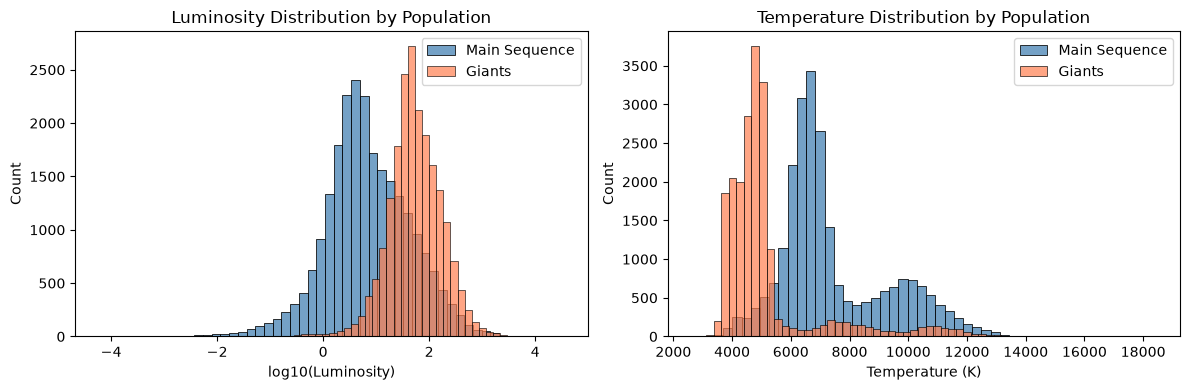

In [3]:
# Plot luminosity and temperature distributions for both populations
# alpha=0.7 makes the coral (giants) layer semi-transparent so both are visible
# Log scale applied to luminosity — confirmed necessary in notebook 02
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(np.log10(df_ms['lum']), ax=axes[0], bins=50, color='steelblue', label='Main Sequence')
sns.histplot(np.log10(df_giant['lum']), ax=axes[0], bins=50, color='coral', alpha=0.7, label='Giants')
axes[0].set_title('Luminosity Distribution by Population')
axes[0].set_xlabel('log10(Luminosity)')
axes[0].legend()

sns.histplot(df_ms['temp'], ax=axes[1], bins=50, color='steelblue', label='Main Sequence')
sns.histplot(df_giant['temp'], ax=axes[1], bins=50, color='coral', alpha=0.7, label='Giants')
axes[1].set_title('Temperature Distribution by Population')
axes[1].set_xlabel('Temperature (K)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [4]:
# Parametric test: independent samples t-test
# Tests whether the means of the two log luminosity distributions are significantly different
# Log transform applied — confirmed approximately normal in notebook 02
t_stat, t_pvalue = stats.ttest_ind(
    np.log10(df_ms['lum']),
    np.log10(df_giant['lum'])
)

# Non-parametric test: Mann-Whitney U
# Tests whether main sequence luminosity tends to be less than giants
# alternative='less' specifies a one-tailed test — we predict MS < giants from physics
# Does not assume normality — robust cross-check against the t-test
u_stat, u_pvalue = stats.mannwhitneyu(
    np.log10(df_ms['lum']),
    np.log10(df_giant['lum']),
    alternative='less'
)

print(f"T-test: statistic={t_stat:.4f}, p-value={t_pvalue:.6f}")
print(f"Mann-Whitney U: statistic={u_stat:.4f}, p-value={u_pvalue:.6f}")

T-test: statistic=-138.3901, p-value=0.000000
Mann-Whitney U: statistic=81509415.0000, p-value=0.000000


## Conclusion

We reject the null hypothesis (H₀) that main sequence stars and giants 
have the same luminosity distribution.

Both the t-test and Mann-Whitney U test returned p-values of essentially 
zero (p << 0.05), meaning the probability of observing this difference 
by random chance is negligible.

The convergence of both a parametric (t-test) and non-parametric 
(Mann-Whitney U) test makes this conclusion robust, therefore it does not depend 
on assumptions about the underlying distribution.

Physically, this confirms what stellar evolution theory predicts: giants 
are significantly more luminous than main sequence stars, and as we saw 
in the temperature plots, they are also cooler whcih makes them consistent with their 
expanded outer layers and position in the upper right of the HR diagram.